In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def load_log_data(log_path=None):
    if log_path is None:
        log_path = os.path.join(os.path.dirname(__file__), "mappo/logs", "training_log.csv")
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Training log not found at: {log_path}")
    return pd.read_csv(log_path)

def set_plot_style():
    plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

def plot_returns(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["mean_return_drone"], label="Drone", color="#0284c7", lw=2, marker="o", ms=4)
    ax.fill_between(
        runs,
        df["mean_return_drone"] - df["std_return_drone"],
        df["mean_return_drone"] + df["std_return_drone"],
        color="#0284c7", alpha=0.15
    )

In [2]:
def plot_returns(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["mean_return_drone"], label="Drone", color="#0284c7", lw=2, marker="o", ms=4)
    ax.fill_between(
        runs,
        df["mean_return_drone"] - df["std_return_drone"],
        df["mean_return_drone"] + df["std_return_drone"],
        color="#0284c7", alpha=0.15
    )

    ax.plot(runs, df["mean_return_rover"], label="Rover", color="#d97706", lw=2, marker="s", ms=4)
    ax.fill_between(
        runs,
        df["mean_return_rover"] - df["std_return_rover"],
        df["mean_return_rover"] + df["std_return_rover"],
        color="#d97706", alpha=0.15
    )

    ax.axhline(0, color="gray", linestyle="--", lw=1, alpha=0.7)
    ax.set_title("Mean Episode Return (± 1 std)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("Return", fontsize=11)
    ax.set_xticks(runs)
    ax.legend(frameon=True, loc="lower right")
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved returns plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

def plot_critic_loss(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["critic_loss"], color="#e11d48", lw=2, marker="o", ms=4, label="Critic MSE Loss")
    ax.set_title("Centralized Critic Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("MSE Loss", fontsize=11)
    ax.set_xticks(runs)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="upper right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved critic loss plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

In [15]:
df = load_log_data("./mappo/logs/training_log.csv")

In [16]:
def plot_returns(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["mean_return_drone"], label="Drone", color="#0284c7", lw=2, marker="o", ms=4)
    ax.fill_between(
        runs,
        df["mean_return_drone"] - df["std_return_drone"],
        df["mean_return_drone"] + df["std_return_drone"],
        color="#0284c7", alpha=0.15
    )

    ax.plot(runs, df["mean_return_rover"], label="Rover", color="#d97706", lw=2, marker="s", ms=4)
    ax.fill_between(
        runs,
        df["mean_return_rover"] - df["std_return_rover"],
        df["mean_return_rover"] + df["std_return_rover"],
        color="#d97706", alpha=0.15
    )

    ax.axhline(0, color="gray", linestyle="--", lw=1, alpha=0.7)
    ax.set_title("Mean Episode Return (± 1 std)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("Return", fontsize=11)
    ax.set_xticks(runs)
    ax.legend(frameon=True, loc="lower right")
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved returns plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

def plot_critic_loss(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["critic_loss"], color="#e11d48", lw=2, marker="o", ms=4, label="Critic MSE Loss")
    ax.set_title("Centralized Critic Loss", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("MSE Loss", fontsize=11)
    ax.set_xticks(runs)
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(frameon=True, loc="upper right")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved critic loss plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

def plot_entropy(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["drone_entropy"], label="Drone Entropy", color="#0284c7", lw=2, marker="o", ms=4)
    ax.plot(runs, df["rover_entropy"], label="Rover Entropy", color="#d97706", lw=2, marker="s", ms=4)
    ax.axhline(1.792, color="gray", linestyle="--", lw=1, alpha=0.7, label="Uniform Max ln(6)")

    ax.set_title("Policy Entropy Decay", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("Entropy", fontsize=11)
    ax.set_xticks(runs)
    ax.legend(frameon=True, loc="upper right")
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved entropy plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

def plot_episode_length(df, save_path=None, show=True):
    set_plot_style()
    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
    runs = df["run"]

    ax.plot(runs, df["mean_ep_length"], color="#7c3aed", lw=2, marker="d", ms=4, label="Mean Ep Length")
    ax.fill_between(
        runs,
        df["mean_ep_length"] - df["std_ep_length"],
        df["mean_ep_length"] + df["std_ep_length"],
        color="#7c3aed", alpha=0.15
    )
    ax.axhline(300, color="gray", linestyle="--", lw=1, alpha=0.7, label="Max Steps (300)")

    ax.set_title("Mean Episode Length", fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Run", fontsize=11)
    ax.set_ylabel("Steps", fontsize=11)
    ax.set_xticks(runs)
    ax.legend(frameon=True, loc="lower right")
    ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print(f"Saved episode length plot to: {save_path}")
    if show:
        plt.show()
    plt.close(fig)

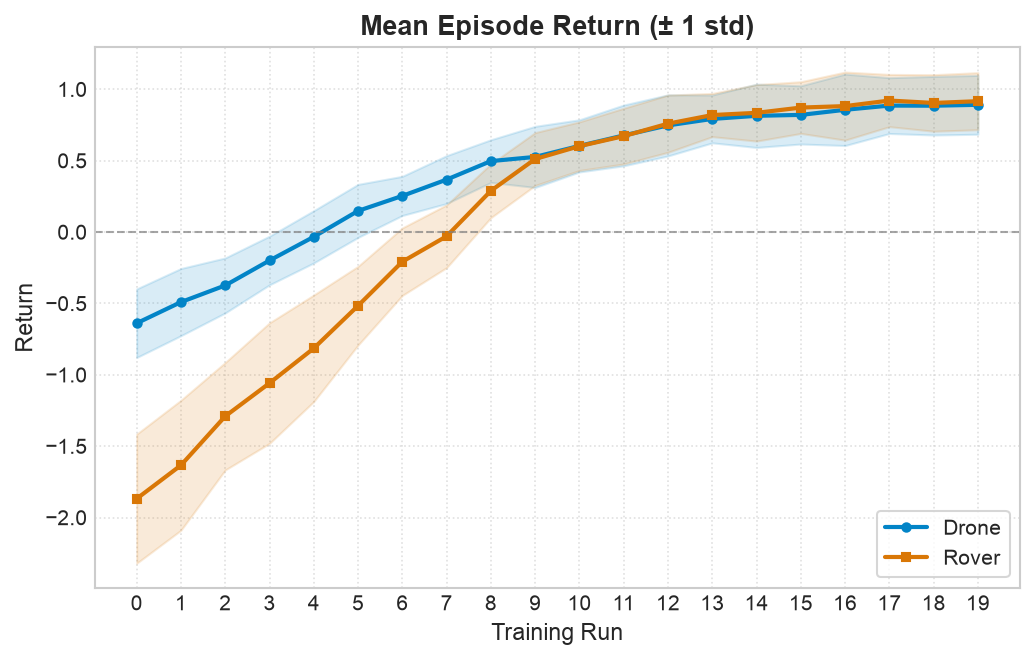

In [17]:
plot_returns(df)

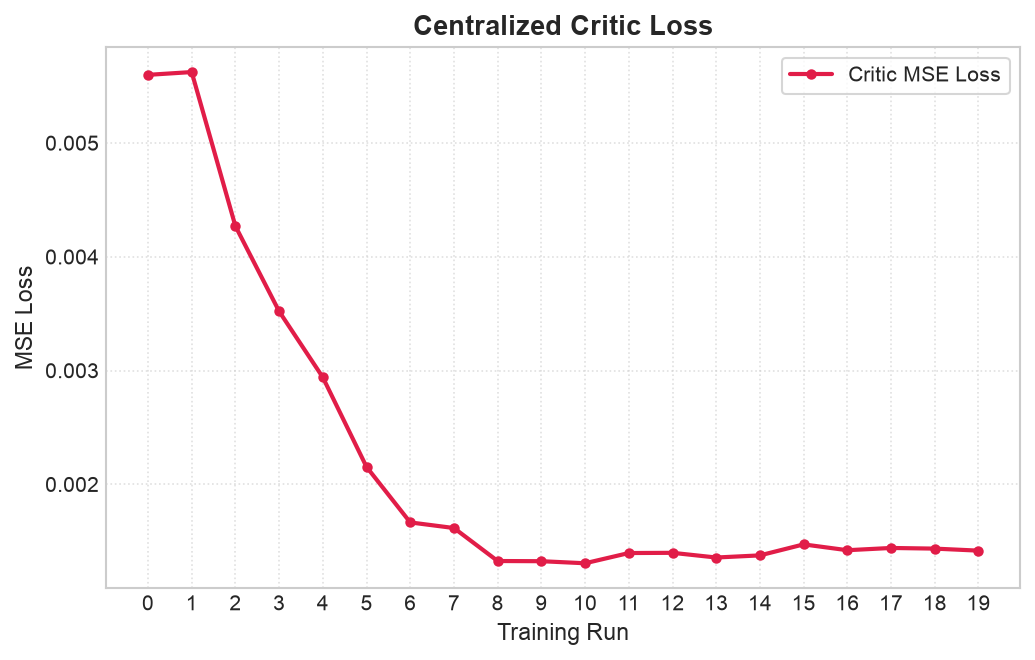

In [18]:
plot_critic_loss(df)

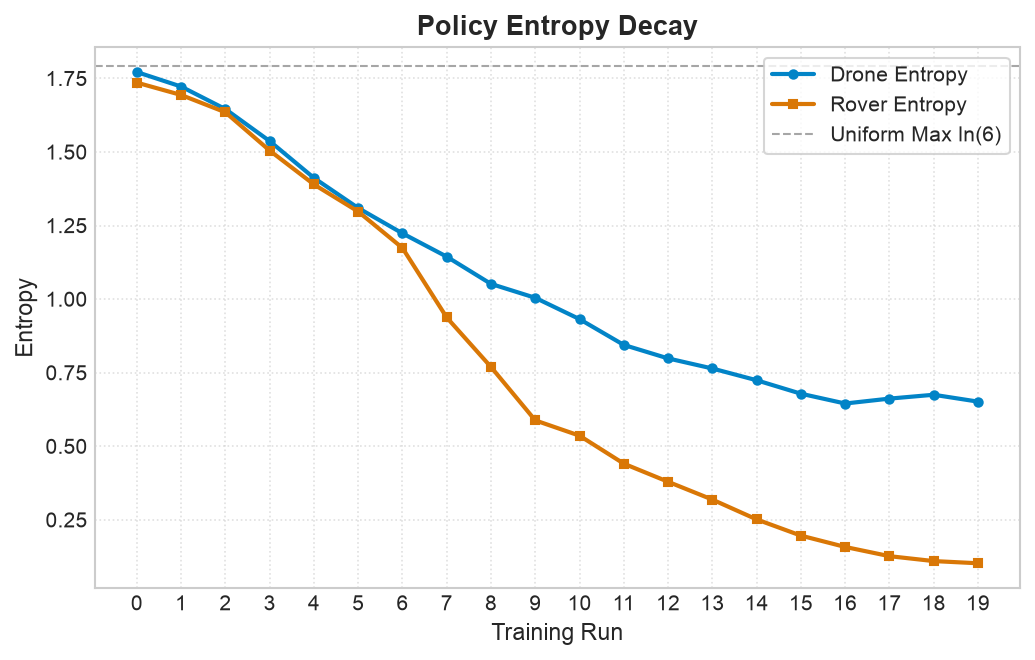

In [19]:
plot_entropy(df)

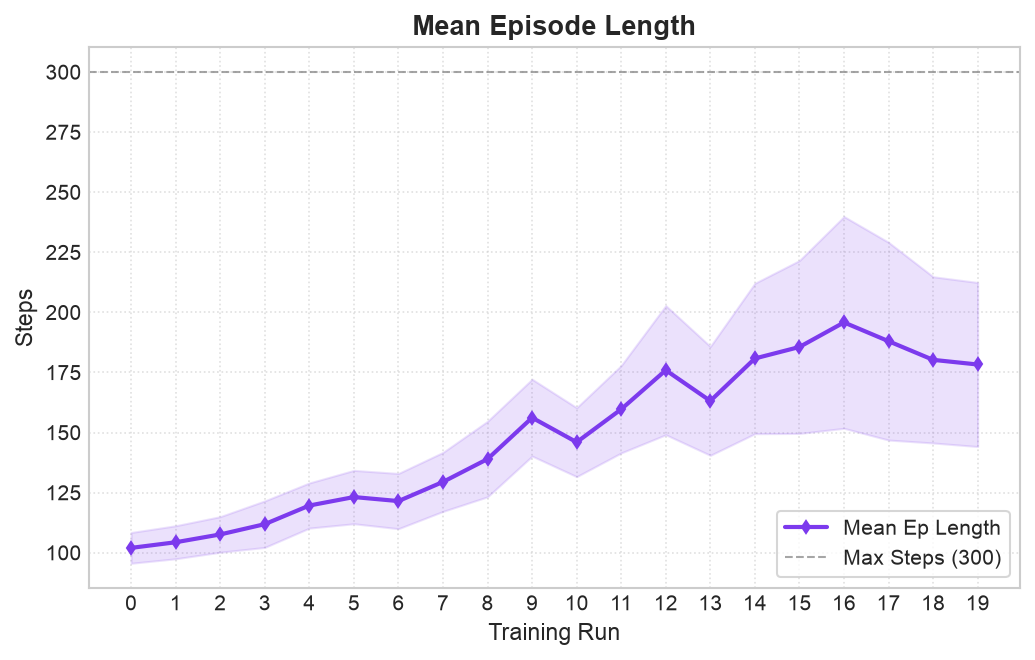

In [20]:
plot_episode_length(df)